In [1]:
!pip install nltk -q

import pandas as pd
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer


In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [3]:
file_path = "/content/amazon_com-product_reviews__20200101_20200331_sample.csv"
df = pd.read_csv(file_path)


In [4]:
print(df.head())


                            Uniq Id            Crawl Timestamp  \
0  10d8b81dc693db8a3f92e19254525d53  2020-03-17 02:32:10 +0000   
1  31ef1ee4961d3fcff33e363edd7677eb  2020-03-17 02:32:10 +0000   
2  6943e517922b051cbec496be32fbb57f  2020-03-17 02:32:10 +0000   
3  6778c794e6ac7112981d4ebb239d6826  2020-03-17 02:32:10 +0000   
4  2335a28ae24db3b2191080bfd98a86e0  2020-03-17 02:32:10 +0000   

                    Billing Uniq Id  Rating  \
0  c697dc43961526785292107b91a639e1     NaN   
1  c697dc43961526785292107b91a639e1     NaN   
2  c697dc43961526785292107b91a639e1     NaN   
3  c697dc43961526785292107b91a639e1     NaN   
4  c697dc43961526785292107b91a639e1     NaN   

                                        Review Title  Review Rating  \
0                           Best Natural Deodorant!!            5.0   
1          Schmidt's Charcoal Deodorant is the best!            5.0   
2                  Beware. Defective or counterfeit.            1.0   
3  Good for infrequent shavers in co

In [5]:
print(df.info())
print(df.isna().sum())

df = df.loc[:, ['Review Content']].dropna()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Uniq Id                50 non-null     object 
 1   Crawl Timestamp        50 non-null     object 
 2   Billing Uniq Id        50 non-null     object 
 3   Rating                 0 non-null      float64
 4   Review Title           50 non-null     object 
 5   Review Rating          50 non-null     float64
 6   Review Date            50 non-null     object 
 7   User Id                50 non-null     object 
 8   Brand                  50 non-null     object 
 9   Category               49 non-null     object 
 10  Sub Category           49 non-null     object 
 11  Product Description    49 non-null     object 
 12  Asin                   50 non-null     object 
 13  Url                    50 non-null     object 
 14  Review Content         50 non-null     object 
 15  Verified

In [6]:
df['Review Content'] = df['Review Content'].str.lower()
df['Tokens'] = df['Review Content'].map(word_tokenize)


In [7]:
stop_words = set(stopwords.words('english'))

df['Clean_Text'] = df['Tokens'].map(
    lambda tokens: [token for token in tokens
                    if token.isalpha() and token not in stop_words]
)


In [8]:
sia = SentimentIntensityAnalyzer()

def sentiment(text):
    compound_score = sia.polarity_scores(" ".join(text))['compound']

    if compound_score >= 0.05:
        return "Positive"
    if compound_score <= -0.05:
        return "Negative"
    return "Neutral"

df['Sentiment'] = df['Clean_Text'].map(sentiment)


In [9]:
print(df.loc[:, ['Review Content', 'Sentiment']].head())
print(df['Sentiment'].value_counts())

count = df['Sentiment'].value_counts()


                                      Review Content Sentiment
0  this is the one natural deodorant that works f...  Negative
1  i am staying away from the conventional deodor...  Positive
2  do not buy this from amazon it's either defect...  Positive
3  i started using this because i was getting cys...  Positive
4  dont buy this from amazon!!!! i never write re...  Negative
Sentiment
Positive    41
Negative     5
Neutral      4
Name: count, dtype: int64


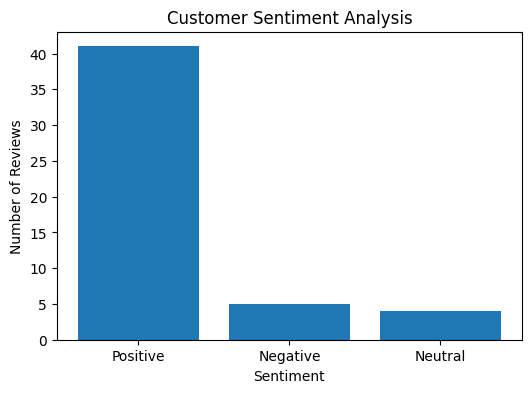

In [10]:
plt.figure(figsize=(6, 4))
plt.bar(count.index, count.to_numpy())
plt.title("Customer Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()


In [11]:
negative = df.loc[df['Sentiment'].eq("Negative")]

print("\nNegative Reviews:")
print(negative['Review Content'].head(10))



Negative Reviews:
0     this is the one natural deodorant that works f...
4     dont buy this from amazon!!!! i never write re...
7     well i stopped using it today. gave it about 3...
9     the only deodorant i’ll ever use anymore, no o...
24    i had to stop using this after two days becaus...
Name: Review Content, dtype: object


In [12]:
print("\nBusiness Insights")
print("---------------------------")
print("Total Reviews :", len(df))
print("Positive Reviews :", df['Sentiment'].eq("Positive").sum())
print("Negative Reviews :", df['Sentiment'].eq("Negative").sum())
print("Neutral Reviews :", df['Sentiment'].eq("Neutral").sum())

if df['Sentiment'].eq("Negative").sum() > 0:
    print("Suggestion: Improve product quality, packaging, delivery, and customer service based on negative reviews.")
else:
    print("Suggestion: Customers are mostly satisfied with the products.")



Business Insights
---------------------------
Total Reviews : 50
Positive Reviews : 41
Negative Reviews : 5
Neutral Reviews : 4
Suggestion: Improve product quality, packaging, delivery, and customer service based on negative reviews.
